In [4]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.ar_model import AutoReg
from data_loader import PairData

data = PairData("../../data/real_pair_MCD_YUM.csv")
q1 = len(data) // 4

jres      = coint_johansen(np.log(data.s[:, :q1]).T, det_order=0, k_ar_diff=1)
cv        = jres.evec[:, 0]
beta      = -cv[1] / cv[0]
intercept = float((np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1])).mean())
spread_q1 = np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1]) - intercept
fixed_std = float(spread_q1.std())

phi       = AutoReg(spread_q1, lags=1).fit().params[1]
half_life = -np.log(2) / np.log(np.clip(phi, 1e-9, 1 - 1e-9))
wn_var    = fixed_std ** 2 * (1 - phi ** 2)

print(f"β = {beta:.4f}  |  intercept = {intercept:.4f}  |  std = {fixed_std:.4f}")
print(f"φ = {phi:.4f}  |  half-life = {half_life:.1f} days  |  wn_var = {wn_var:.6f}")

β = 1.0437  |  intercept = 0.5396  |  std = 0.1157
φ = 0.9893  |  half-life = 64.7 days  |  wn_var = 0.000284


In [5]:
N = 200   # number of independent series
T = 1258  # length of each series (= Q2 training window)

s1_init = 100.0
s0_init = s1_init ** beta * np.exp(intercept)
print(f"s0 initial: {s0_init:.2f}  |  s1 initial: {s1_init:.2f}")
print(f"Spread formula: log(s0) − {beta:.3f}·log(s1) − {intercept:.3f}")

# GBM for s1 — shape (N, T)
log_s1 = np.zeros((N, T))
log_s1[:, 0] = np.log(s1_init)
log_s1[:, 1:] = 0.0005 + 0.015 * np.random.randn(N, T - 1)
log_s1 = np.cumsum(log_s1, axis=1)

# AR(1) spread — shape (N, T)
noise = np.sqrt(wn_var) * np.random.randn(N, T)
spread_all = np.zeros((N, T))
for t in range(1, T):
    spread_all[:, t] = phi * spread_all[:, t - 1] + noise[:, t]

# s0 from cointegration: log(s0) = beta*log(s1) + intercept + spread
log_s0 = beta * log_s1 + intercept + spread_all
s0_all = np.exp(log_s0)  # (N, T)
s1_all = np.exp(log_s1)  # (N, T)

# Stack to (N, 2, T) and save
pairs = np.stack([s0_all, s1_all], axis=1)
np.save("../../data/synthetic_MCD_YUM_pairs.npy", pairs)
print(f"Saved {N} series of length {T} → data/synthetic_MCD_YUM_pairs.npy  shape={pairs.shape}")
print(f"Spread std (mean over series): {spread_all.std(axis=1).mean():.4f}  (target: {fixed_std:.4f})")

# Keep first series for plotting
s0, s1, spread = s0_all[0], s1_all[0], spread_all[0]

s0 initial: 209.73  |  s1 initial: 100.00
Spread formula: log(s0) − 1.044·log(s1) − 0.540
Saved 200 series of length 1258 → data/synthetic_MCD_YUM_pairs.npy  shape=(200, 2, 1258)
Spread std (mean over series): 0.1058  (target: 0.1157)


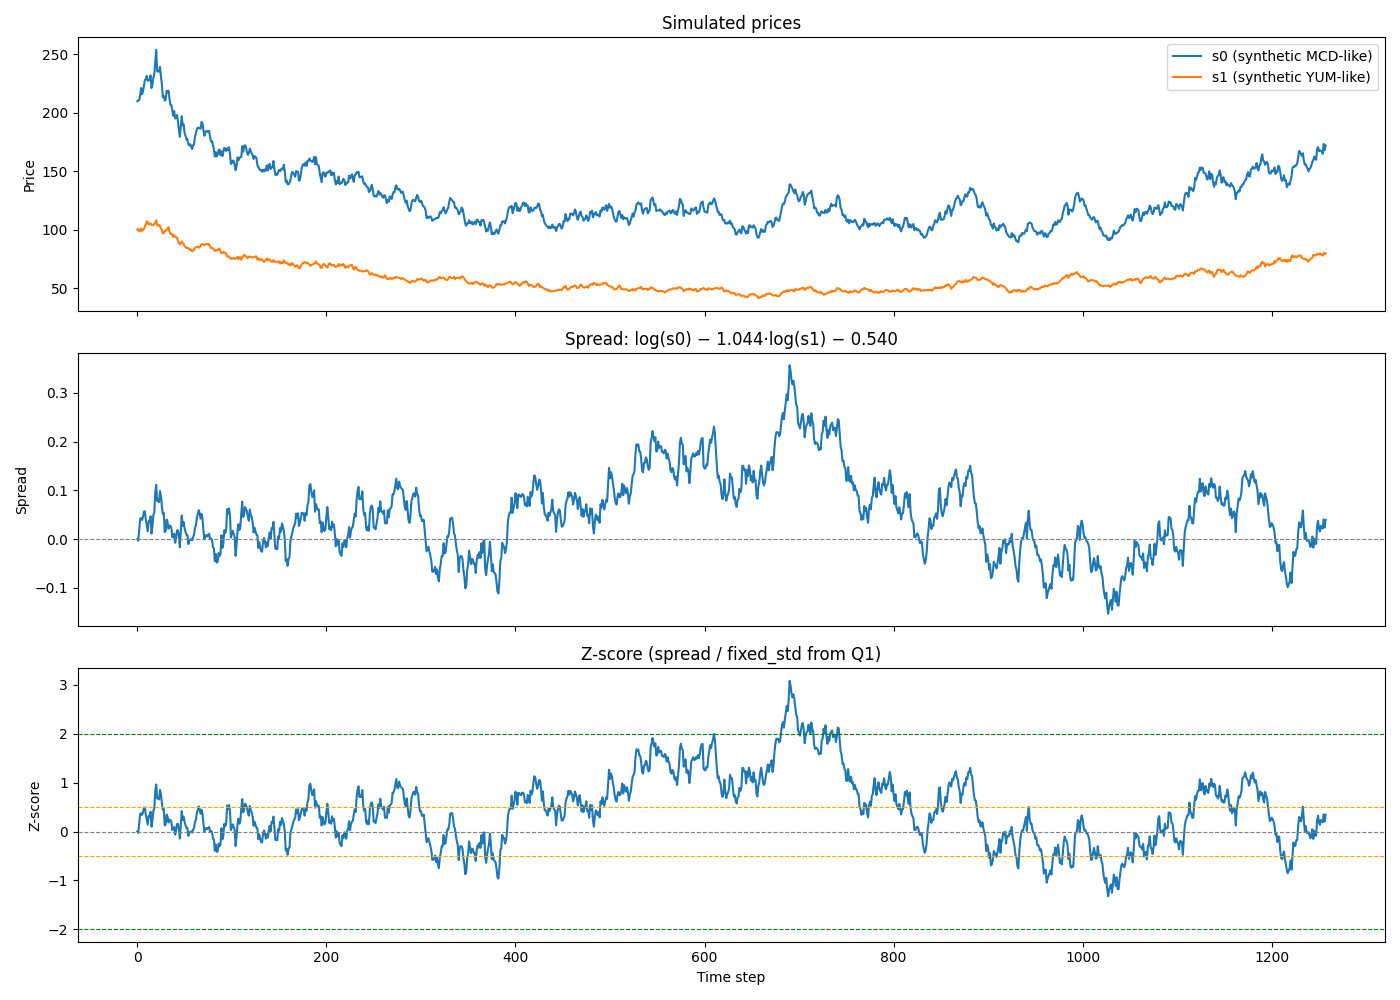

In [6]:
%matplotlib widget

zscore = spread / fixed_std

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(s0, label="s0 (synthetic MCD-like)")
axes[0].plot(s1, label="s1 (synthetic YUM-like)")
axes[0].set_title("Simulated prices")
axes[0].set_ylabel("Price")
axes[0].legend()

axes[1].plot(spread)
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Spread: log(s0) − {beta:.3f}·log(s1) − {intercept:.3f}")
axes[1].set_ylabel("Spread")

axes[2].plot(zscore)
axes[2].axhline(0,    color="gray",   linewidth=0.8, linestyle="--")
axes[2].axhline( 2.0, color="green",  linewidth=0.8, linestyle="--")
axes[2].axhline(-2.0, color="green",  linewidth=0.8, linestyle="--")
axes[2].axhline( 0.5, color="orange", linewidth=0.8, linestyle="--")
axes[2].axhline(-0.5, color="orange", linewidth=0.8, linestyle="--")
axes[2].set_title("Z-score (spread / fixed_std from Q1)")
axes[2].set_ylabel("Z-score")
axes[2].set_xlabel("Time step")

plt.tight_layout()
plt.show()